In [7]:
from typing import Annotated, Literal, Sequence, TypedDict

from pydantic import BaseModel, Field

from langchain_core.messages import BaseMessage, HumanMessage
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import PromptTemplate

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode, tools_condition

from langchain_community.document_loaders import WebBaseLoader
from langchain_chroma import Chroma
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.tools import create_retriever_tool

## we will load the open source embedding model

In [14]:
from dotenv import load_dotenv
load_dotenv()

True

In [9]:
from langchain_huggingface import HuggingFaceEmbeddings


In [11]:
embeddings = HuggingFaceEmbeddings(model_name="all-MiniLM-L6-v2")


C:\Users\DEV SAHU\AppData\Roaming\Python\Python313\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\DEV SAHU\.cache\huggingface\hub\models--sentence-transformers--all-MiniLM-L6-v2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed.

In [12]:
from langchain_groq import ChatGroq


In [15]:
llm=ChatGroq(model="llama-3.1-8b-instant")

In [16]:
llm.invoke("what is adwait philosophy?")

AIMessage(content='Advaita Vedanta, also known as Advaita philosophy, is a school of thought within Hinduism that emerged in the 8th century CE. It is based on the teachings of Adi Shankaracharya (788-820 CE), who is considered one of the greatest philosophers of India.\n\nThe core concept of Advaita Vedanta is the ultimate reality, known as Brahman, which is the unchanging, all-pervading, and eternal essence of the universe. Brahman is often described as the Absolute, the Infinite, and the Unknowable.\n\nThe key principles of Advaita Vedanta are:\n\n1. **Non-duality (Advaita)**: The ultimate reality, Brahman, is not separate from the individual self (Atman). There is no distinction between the two; they are ultimately one and the same.\n2. **Illusion of the world (Maya)**: The world we experience through our senses is an illusion, a projection of Brahman. It is impermanent and ephemeral, whereas Brahman is eternal and unchanging.\n3. **The individual self (Atman)**: The Atman is not a

### task for the project
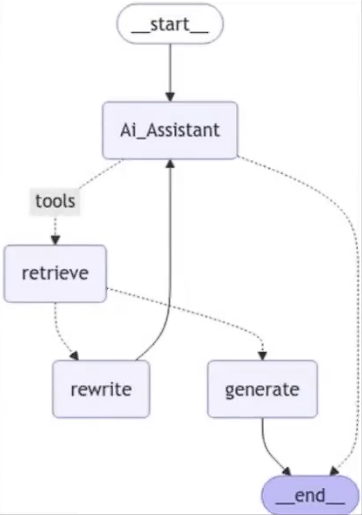

In [24]:
urls = [
    "https://lilianweng.github.io/posts/2023-06-23-agent/",
    "https://lilianweng.github.io/posts/2023-03-15-prompt-engineering/",
]

In [26]:
docx = [WebBaseLoader(url).load() for url in urls] ## list compression
docx


[[Document(metadata={'source': 'https://lilianweng.github.io/posts/2023-06-23-agent/', 'title': "LLM Powered Autonomous Agents | Lil'Log", 'description': 'Building agents with LLM (large language model) as its core controller is a cool concept. Several proof-of-concepts demos, such as AutoGPT, GPT-Engineer and BabyAGI, serve as inspiring examples. The potentiality of LLM extends beyond generating well-written copies, stories, essays and programs; it can be framed as a powerful general problem solver.\nAgent System Overview\nIn a LLM-powered autonomous agent system, LLM functions as the agent’s brain, complemented by several key components:\n\nPlanning\n\nSubgoal and decomposition: The agent breaks down large tasks into smaller, manageable subgoals, enabling efficient handling of complex tasks.\nReflection and refinement: The agent can do self-criticism and self-reflection over past actions, learn from mistakes and refine them for future steps, thereby improving the quality of final res

In [27]:
docx[0][0].metadata

{'source': 'https://lilianweng.github.io/posts/2023-06-23-agent/',
 'title': "LLM Powered Autonomous Agents | Lil'Log",
 'description': 'Building agents with LLM (large language model) as its core controller is a cool concept. Several proof-of-concepts demos, such as AutoGPT, GPT-Engineer and BabyAGI, serve as inspiring examples. The potentiality of LLM extends beyond generating well-written copies, stories, essays and programs; it can be framed as a powerful general problem solver.\nAgent System Overview\nIn a LLM-powered autonomous agent system, LLM functions as the agent’s brain, complemented by several key components:\n\nPlanning\n\nSubgoal and decomposition: The agent breaks down large tasks into smaller, manageable subgoals, enabling efficient handling of complex tasks.\nReflection and refinement: The agent can do self-criticism and self-reflection over past actions, learn from mistakes and refine them for future steps, thereby improving the quality of final results.\n\n\nMemory\

In [28]:
docx_list = [item for sublist in docx for item in sublist]

In [29]:
text_splitter = RecursiveCharacterTextSplitter.from_tiktoken_encoder(chunk_size=100,chunk_overlap=20)



In [ ]:
docx_split = text_splitter.split_documents(docx_list) ## all the splitted docs

In [34]:
VectorStore = Chroma.from_documents(
    documents = docx_split,
    collection_name = "rag-chrome",
    embedding = embeddings
)

In [35]:
Retriever = VectorStore.as_retriever()

In [37]:
retriever_tool = create_retriever_tool(
    Retriever,
    "retreiver_blog_post",
    "Search and return information abnout the page and do not hallucinate say only much it si required"

)

In [39]:
tools = [retriever_tool]

In [40]:
def AI_Assistant(state):
    print("----CALL AGENT----")
    messages = state['messages']
    model_with_tool = llm.bind_tools(tools)
    response = model_with_tool.invoke(messages)
    return {"messages": [response]}


In [51]:
from langchain_core.messages import HumanMessage

def rewrite(state):
    print("---TRANSFORM QUERY---")

    question = state["messages"][0].content

    msg = [
        HumanMessage(
            content=f""" \n
Look at the input and try to reason about the underlying semantic intent or meaning.

Here is the initial question:
\n ------ \n
{question}

Formulate an improved question:
"""
        )
    ]

    response = llm.invoke(msg)

    return {
        "messages": [response]
    }

In [78]:
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser

def generate(state):
    print("---GENERATE---")

    messages = state["messages"]
    question = messages[0].content
    docs = messages[-1].content

    prompt = ChatPromptTemplate.from_template(
        """
You are an assistant for question-answering tasks.

Use the following retrieved context to answer the user's question.
If you don't know the answer, just say that you don't know.
Keep the answer concise.

Context:
{context}

Question:
{question}

Answer:
"""
    )

    rag_chain = prompt | llm | StrOutputParser()

    response = rag_chain.invoke(
        {
            "context": docs,
            "question": question,
        }
    )

    return {"messages": [response]}

In [79]:
class grade(BaseModel):
    binary_score:str = Field(description="Relevamce score 'yes' or 'no'")

In [80]:
def grade_documents(state: AgentState):
    llm_with_structure_op = llm.with_structured_output(grade)

    prompt = PromptTemplate(
        template="""You are a grader assessing relevance of a retrieved document to a user question. \n
Here is the retrieved document: \n\n {context} \n\n
Here is the user question: {question} \n
If the document contains keyword(s) or semantic meaning related to the user question, grade it as relevant. \n
Give a binary score "yes" or "no" score to indicate whether the document is relevant to the question.""",
        input_variables=["context", "question"],
    )

    chain = prompt | llm_with_structure_op

    messages = state["messages"]
    last_message = messages[-1]

    question = messages[0].content
    docs = last_message.content

    scored_result = chain.invoke({"question": question, "context": docs})

    score = scored_result.binary_score

    if score == "yes":
        print("---DECISION: DOCS RELEVANT---")
        return "generator"
    else :
        print("decision not relevent")
        return "rewriter"

In [81]:
class AgentState(TypedDict):
    messages: Annotated[Sequence[BaseMessage], add_messages]

In [82]:
workflow = StateGraph(AgentState)
workflow.add_node("ai",AI_Assistant)
retrieve = ToolNode([retriever_tool])
workflow.add_node("retriever",retrieve)
workflow.add_node("rewriter",rewrite)
workflow.add_node("generator",generate)


In [83]:
workflow.add_edge(START,"ai")
workflow.add_conditional_edges("ai",tools_condition, 
                               {"tools":"retriever",
                                END:END,} )




In [84]:
workflow.add_conditional_edges("retriever",
                               grade_documents,
                               {"rewriter":"rewriter",
                                "generator":"generator"})

In [85]:
workflow.add_edge("generator",END)

In [86]:
workflow.add_edge("rewriter","ai")

In [87]:
app = workflow.compile()

In [89]:
from langchain_core.messages import HumanMessage

app.invoke(
    {
        "messages": [
            HumanMessage(content="Explain self reflection?")
        ]
    }
)

----CALL AGENT----
---DECISION: DOCS RELEVANT---
---GENERATE---


{'messages': [HumanMessage(content='Explain self reflection?', additional_kwargs={}, response_metadata={}, id='ee8983e8-6129-4a32-9f76-276c226abfba'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'tc8ew6tzx', 'function': {'arguments': '{"query":"What is self reflection?"}', 'name': 'retreiver_blog_post'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 21, 'prompt_tokens': 259, 'total_tokens': 280, 'completion_time': 0.042110428, 'completion_tokens_details': None, 'prompt_time': 0.030621269, 'prompt_tokens_details': None, 'queue_time': 0.158762578, 'total_time': 0.072731697}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_7ccc667439', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f5bfc-d0b0-7ca3-942e-987109cca5f2-0', tool_calls=[{'name': 'retreiver_blog_post', 'args': {'query': 'What is self reflection?'}, 'id': 'tc8ew6tzx', 'type': 'tool_call'}]

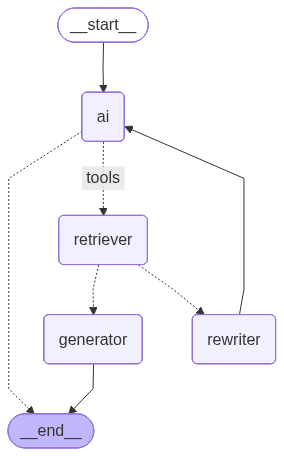

In [90]:
from IPython.display import Image, display
from langchain_core.runnables.graph import MermaidDrawMethod

display(
    Image(
        app.get_graph().draw_mermaid_png(
            draw_method=MermaidDrawMethod.API,
        )
    )
)